KMeans clustering on the same customer-segmentation data style as `09-hierarchical-clustering/`, but using centroid-based partitioning instead of a merge tree. Covers the elbow method and silhouette score for choosing K.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Same style of customer data as 09-hierarchical-clustering, three natural groups
data = {
    'CustomerID': [f'C{i+1}' for i in range(15)],
    'AnnualSpending':  [15, 18, 20, 22, 25,
                        80, 85, 90, 88, 82,
                        45, 48, 50, 52, 47],
    'VisitsPerMonth':  [12, 14, 11, 13, 15,
                        6, 5, 7, 8, 6,
                        2, 3, 2, 1, 3],
}
df = pd.DataFrame(data)

X = df[['AnnualSpending', 'VisitsPerMonth']].values
X_scaled = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
print(df)

   CustomerID  AnnualSpending  VisitsPerMonth
0          C1              15              12
1          C2              18              14
2          C3              20              11
3          C4              22              13
4          C5              25              15
5          C6              80               6
6          C7              85               5
7          C8              90               7
8          C9              88               8
9         C10              82               6
10        C11              45               2
11        C12              48               3
12        C13              50               2
13        C14              52               1
14        C15              47               3


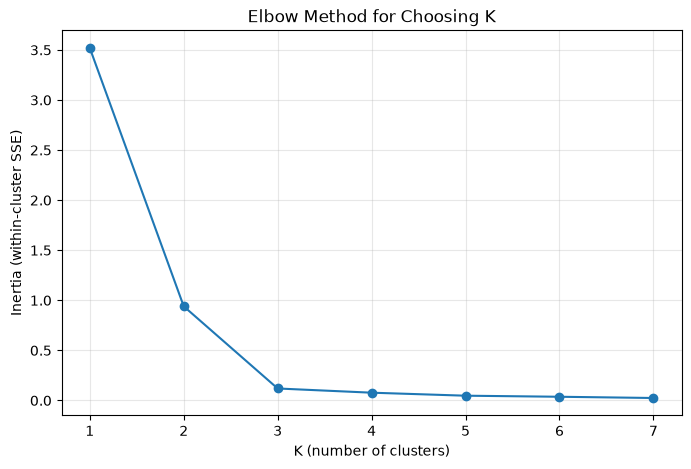

In [2]:
# Elbow method: plot inertia (within-cluster sum of squares) vs K
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'o-')
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia (within-cluster SSE)')
plt.title('Elbow Method for Choosing K')
plt.grid(True, alpha=0.3)
plt.show()

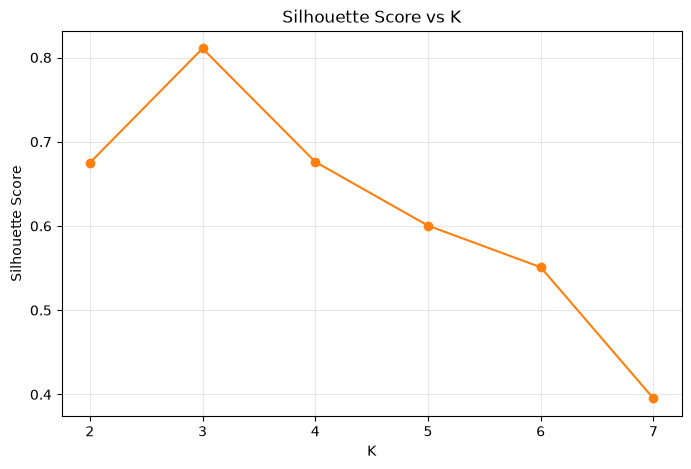

Best K by silhouette score: 3


In [3]:
# Silhouette score: how well-separated and cohesive the clusters are (higher is better, max 1.0)
sil_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), sil_scores, 'o-', color='tab:orange')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(range(2, 8))[int(np.argmax(sil_scores))]
print(f"Best K by silhouette score: {best_k}")

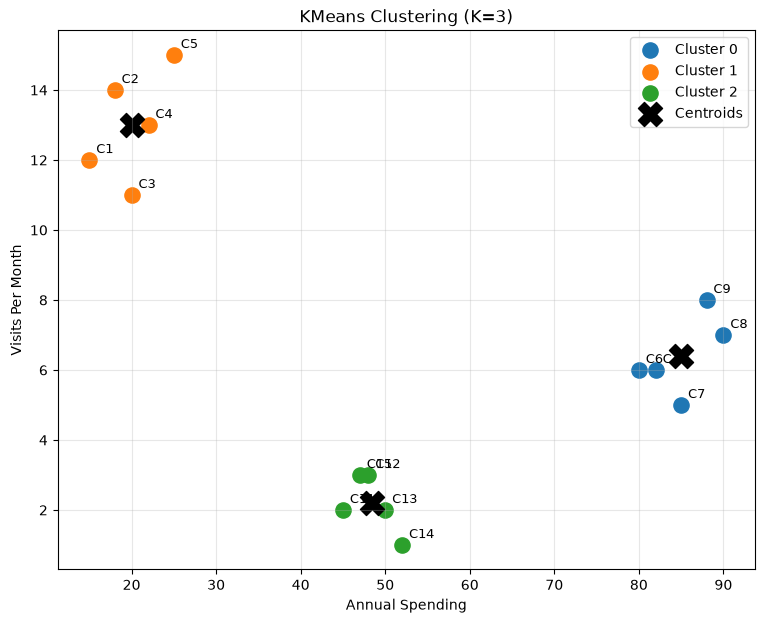

   CustomerID  AnnualSpending  VisitsPerMonth  cluster
0          C1              15              12        1
1          C2              18              14        1
2          C3              20              11        1
3          C4              22              13        1
4          C5              25              15        1
5          C6              80               6        0
6          C7              85               5        0
7          C8              90               7        0
8          C9              88               8        0
9         C10              82               6        0
10        C11              45               2        2
11        C12              48               3        2
12        C13              50               2        2
13        C14              52               1        2
14        C15              47               3        2


In [4]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = final_km.fit_predict(X_scaled)

plt.figure(figsize=(9, 7))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for c in range(best_k):
    mask = df['cluster'] == c
    plt.scatter(df.loc[mask, 'AnnualSpending'], df.loc[mask, 'VisitsPerMonth'],
                s=120, color=colors[c % len(colors)], label=f'Cluster {c}')

centroids_unscaled = final_km.cluster_centers_ * (X.max(axis=0) - X.min(axis=0)) + X.min(axis=0)
plt.scatter(centroids_unscaled[:, 0], centroids_unscaled[:, 1],
            marker='X', s=300, color='black', label='Centroids')

for i, txt in enumerate(df['CustomerID']):
    plt.annotate(txt, (df['AnnualSpending'][i], df['VisitsPerMonth'][i]), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Annual Spending')
plt.ylabel('Visits Per Month')
plt.title(f'KMeans Clustering (K={best_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(df)

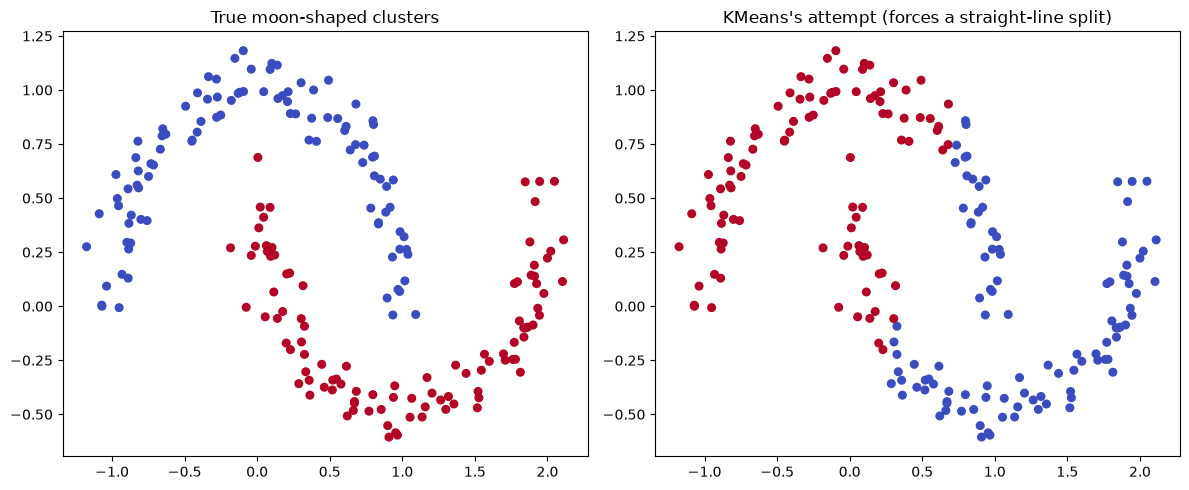

KMeans can only carve convex regions -- it cannot follow the curved boundary between the moons.
See 20-dbscan-clustering/ for a density-based method that handles this correctly.


In [5]:
# KMeans assumes convex, roughly-spherical clusters. Show where it struggles:
# non-convex (moon-shaped) data.
from sklearn.datasets import make_moons
Xm, ym_true = make_moons(n_samples=200, noise=0.08, random_state=42)

km_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km_moons.fit_predict(Xm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(Xm[:, 0], Xm[:, 1], c=ym_true, cmap='coolwarm', s=30)
axes[0].set_title('True moon-shaped clusters')
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=km_labels, cmap='coolwarm', s=30)
axes[1].set_title("KMeans's attempt (forces a straight-line split)")
plt.tight_layout()
plt.show()
print("KMeans can only carve convex regions -- it cannot follow the curved boundary between the moons.")
print("See 20-dbscan-clustering/ for a density-based method that handles this correctly.")